## Setup e ricerca dei film su TMDB

In [1]:
import sys
sys.path.append("..")
import os
import requests
from dotenv import load_dotenv

# carichiamo la chiave TMDB
load_dotenv("../.env")
api_key = os.getenv("TMDB_API_KEY")
print("Chiave caricata:", api_key[:6], "...")

# la lista dei film d'autore che vogliamo analizzare
film_autore = [
    "The Florida Project",
    "All These Sleepless Nights",
    "The Worst Person in the World",
    "American Honey",
    "Fish Tank",
    "Mommy",
    "Laurence Anyways",
    "The Elephant Man",
    "Eternal Sunshine of the Spotless Mind",
]

print("Film da analizzare:", len(film_autore))

/Users/Maddalena/Documents/color-in-motion/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Chiave caricata: cecade ...
Film da analizzare: 9


## Ricerca trailer su TMDB (con gestione errori)

In [2]:
risultati_autore = []

for titolo in film_autore:
    try:
        # cerca il film
        url_search = "https://api.themoviedb.org/3/search/movie"
        params = {"api_key": api_key, "query": titolo}
        r = requests.get(url_search, params=params)
        risultati = r.json()["results"]

        if not risultati:
            print("NON trovato:", titolo)
            continue

        film = risultati[0]
        tmdb_id = film["id"]
        anno = film.get("release_date", "")[:4]

        # cerca il trailer
        url_videos = f"https://api.themoviedb.org/3/movie/{tmdb_id}/videos"
        r = requests.get(url_videos, params={"api_key": api_key})
        video = r.json()["results"]

        link = None
        for v in video:
            if v["type"] == "Trailer" and v["site"] == "YouTube":
                link = "https://www.youtube.com/watch?v=" + v["key"]
                break

        risultati_autore.append({
            "titolo": titolo,
            "anno": anno,
            "tmdb_id": tmdb_id,
            "trailer_link": link,
        })
        print(f"OK: {titolo} ({anno}) - trailer: {'si' if link else 'NO'}")

    except Exception as e:
        print(f"ERRORE su {titolo}: {e}")

print("\nFilm salvati:", len(risultati_autore))

OK: The Florida Project (2017) - trailer: si
OK: All These Sleepless Nights (2016) - trailer: si
OK: The Worst Person in the World (2021) - trailer: si
OK: American Honey (2016) - trailer: si
OK: Fish Tank (2009) - trailer: si
OK: Mommy (2026) - trailer: si
OK: Laurence Anyways (2012) - trailer: si
OK: The Elephant Man (1980) - trailer: si
OK: Eternal Sunshine of the Spotless Mind (2004) - trailer: si

Film salvati: 9


## Correzione: Mommy aveva preso il film sbagliato

In [3]:
# Mommy aveva preso il film sbagliato: correggiamo con l'id di Dolan (2014)
mommy_id = 265177

# recuperiamo il trailer del Mommy giusto
url_videos = f"https://api.themoviedb.org/3/movie/{mommy_id}/videos"
r = requests.get(url_videos, params={"api_key": api_key})
video = r.json()["results"]

link = None
for v in video:
    if v["type"] == "Trailer" and v["site"] == "YouTube":
        link = "https://www.youtube.com/watch?v=" + v["key"]
        break

# aggiorniamo il record di Mommy nella lista
for film in risultati_autore:
    if film["titolo"] == "Mommy":
        film["anno"] = "2014"
        film["tmdb_id"] = mommy_id
        film["trailer_link"] = link

print("Mommy corretto - trailer:", "si" if link else "NO")

# ricontrolliamo tutta la lista
for film in risultati_autore:
    print(film["titolo"], "-", film["anno"], "-", "trailer si" if film["trailer_link"] else "trailer NO")

Mommy corretto - trailer: si
The Florida Project - 2017 - trailer si
All These Sleepless Nights - 2016 - trailer si
The Worst Person in the World - 2021 - trailer si
American Honey - 2016 - trailer si
Fish Tank - 2009 - trailer si
Mommy - 2014 - trailer si
Laurence Anyways - 2012 - trailer si
The Elephant Man - 1980 - trailer si
Eternal Sunshine of the Spotless Mind - 2004 - trailer si


## Salvataggio della source table

In [4]:
import pandas as pd

# salviamo la lista come CSV
autore_df = pd.DataFrame(risultati_autore)
autore_df.to_csv("../data/source/auteur_films.csv", index=False)
print("Salvato:", len(autore_df), "film d'autore")
autore_df

Salvato: 9 film d'autore


,titolo,anno,tmdb_id,trailer_link
0,The Florida Project,2017,394117,https://www.youtube.com/watch?v=WwQ-NH1rRT4
1,All These Sleepless Nights,2016,376386,https://www.youtube.com/watch?v=toRRACvGp60
2,The Worst Person in the World,2021,660120,https://www.youtube.com/watch?v=gpkQgk1Fi1Q
3,American Honey,2016,340485,https://www.youtube.com/watch?v=y1SpWZm1PLc
4,Fish Tank,2009,24469,https://www.youtube.com/watch?v=xf5VOvB5MHA
5,Mommy,2014,265177,https://www.youtube.com/watch?v=PlZB2LLjzZY
6,Laurence Anyways,2012,110160,https://www.youtube.com/watch?v=Y-CX4bRqJzw
7,The Elephant Man,1980,1955,https://www.youtube.com/watch?v=kxb_1457gGs
8,Eternal Sunshine of the Spotless Mind,2004,38,https://www.youtube.com/watch?v=c2e-bj6qy8Y


## Download dei trailer

In [5]:
import os
import yt_dlp

# cartella dedicata ai trailer d'autore
os.makedirs("../data/raw/auteur_trailers", exist_ok=True)

for film in risultati_autore:
    titolo = film["titolo"]
    link = film["trailer_link"]
    # nome file pulito: usiamo il tmdb_id
    output = f"../data/raw/auteur_trailers/{film['tmdb_id']}.mp4"

    if os.path.exists(output):
        print("gia scaricato:", titolo)
        continue

    opzioni = {
        "format": "best[height<=480]/best",
        "outtmpl": output,
        "extractor_args": {"youtube": {"player_client": ["android"]}},
        "quiet": True,
    }

    try:
        with yt_dlp.YoutubeDL(opzioni) as ydl:
            ydl.download([link])
        print("OK:", titolo)
    except Exception as e:
        print("FALLITO:", titolo)

gia scaricato: The Florida Project
gia scaricato: All These Sleepless Nights
gia scaricato: The Worst Person in the World
gia scaricato: American Honey
gia scaricato: Fish Tank
gia scaricato: Mommy
gia scaricato: Laurence Anyways
gia scaricato: The Elephant Man
gia scaricato: Eternal Sunshine of the Spotless Mind


## Estrazione del colore

In [6]:
from src.frames import extract_frames
from src.metrics import curve_from_frames
import numpy as np

cartella = "../data/raw/auteur_trailers"

# per ogni film teniamo sia le sequenze complete sia i riassunti
auteur_data = []

for film in risultati_autore:
    tmdb_id = film["tmdb_id"]
    percorso = f"{cartella}/{tmdb_id}.mp4"

    frames = extract_frames(percorso, per_second=1)
    brightness, temperature, saturation, colours = curve_from_frames(frames)

    auteur_data.append({
        "titolo": film["titolo"],
        "anno": film["anno"],
        "brightness_media": np.mean(brightness),
        "saturation_media": np.mean(saturation),
        "temperature_media": np.mean(temperature),
        "colours": colours,   # sequenza completa per il barcode
    })
    print("Fatto:", film["titolo"])

print("\nFinito! Film processati:", len(auteur_data))

Fatto: The Florida Project
Fatto: All These Sleepless Nights
Fatto: The Worst Person in the World
Fatto: American Honey
Fatto: Fish Tank
Fatto: Mommy
Fatto: Laurence Anyways
Fatto: The Elephant Man
Fatto: Eternal Sunshine of the Spotless Mind

Finito! Film processati: 9


## Movie barcodes

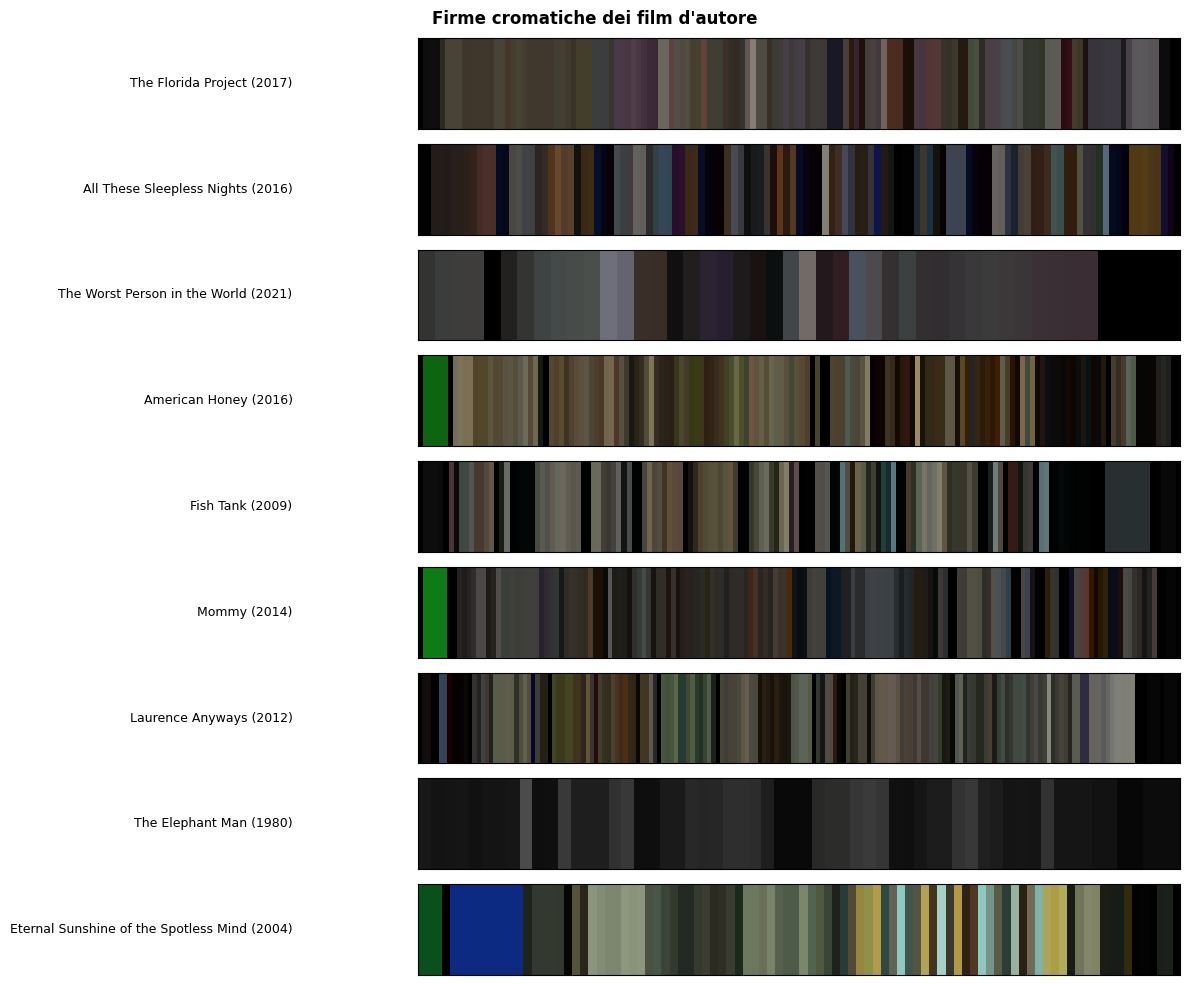

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(len(auteur_data), 1, figsize=(12, 10))

for i, film in enumerate(auteur_data):
    colours = film["colours"]
    immagine = np.array(colours).reshape(1, len(colours), 3)

    axes[i].imshow(immagine, aspect="auto")
    axes[i].set_yticks([])
    axes[i].set_xticks([])
    # titolo del film a sinistra
    etichetta = f"{film['titolo']} ({film['anno']})"
    axes[i].set_ylabel(etichetta, rotation=0, labelpad=90, va="center", ha="right", fontsize=9)

plt.suptitle("Firme cromatiche dei film d'autore", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/barcode_auteur.png", dpi=120, bbox_inches="tight")
plt.show()

## Filtro dei frame-cartello (criterio adattivo)

Fatto: The Florida Project - frame scartati: 8 su 140
Fatto: All These Sleepless Nights - frame scartati: 11 su 117
Fatto: The Worst Person in the World - frame scartati: 5 su 46
Fatto: American Honey - frame scartati: 16 su 152
Fatto: Fish Tank - frame scartati: 32 su 150
Fatto: Mommy - frame scartati: 17 su 157
Fatto: Laurence Anyways - frame scartati: 16 su 182
Fatto: The Elephant Man - frame scartati: 18 su 60
Fatto: Eternal Sunshine of the Spotless Mind - frame scartati: 29 su 94

Finito!


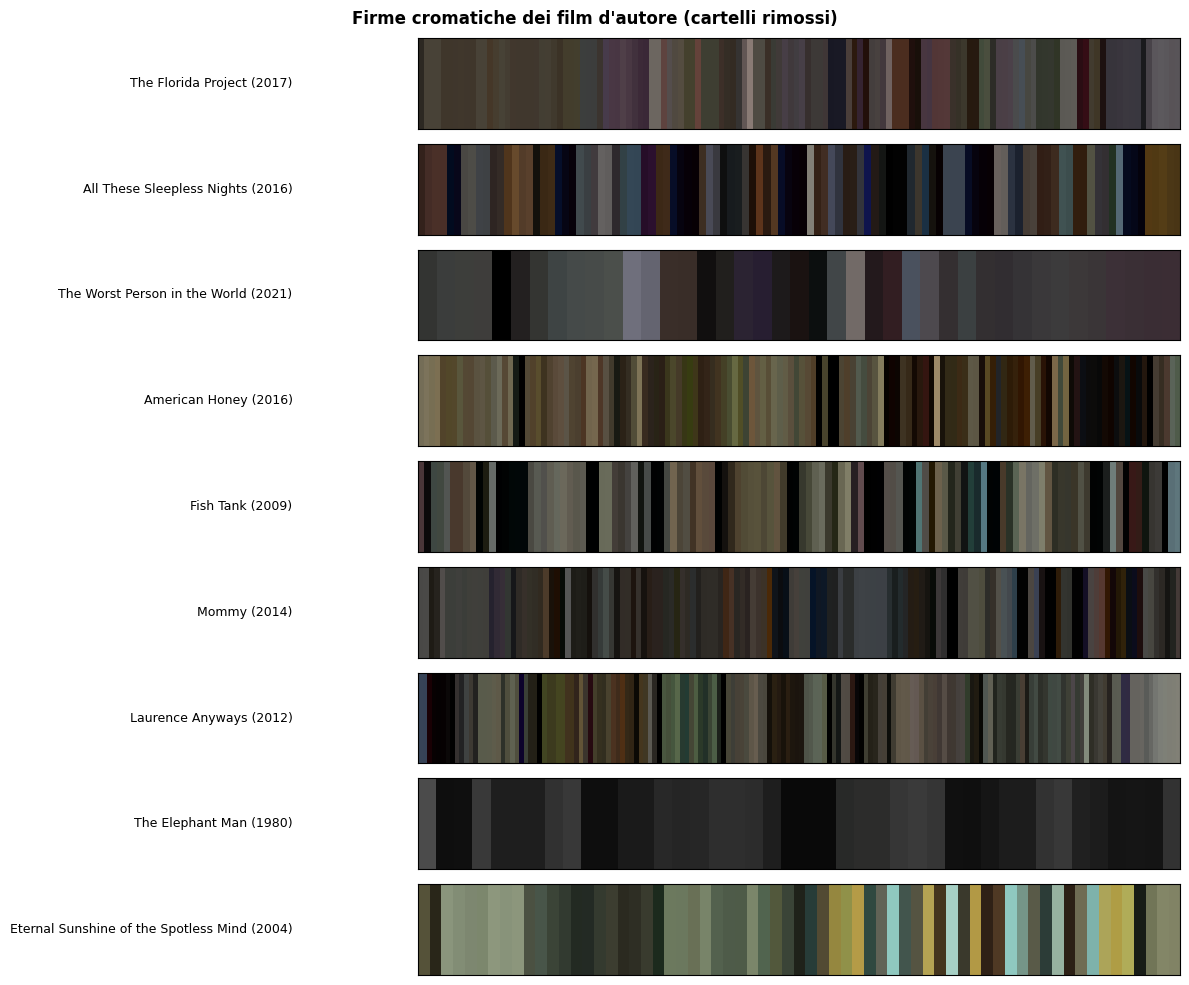


Con il criterio adattivo, i cartelli lunghi (es. Eternal Sunshine) ora
vengono scartati per intero, qualunque sia la loro durata reale.


In [8]:
# togliamo i frame-cartello anche dai barcode dei film d'autore
# criterio ADATTIVO: invece di una finestra fissa di N secondi (che non si
# adatta a cartelli piu' lunghi, es. Eternal Sunshine), camminiamo dall'inizio
# del trailer finche' i frame restano uniformi, e ci fermiamo appena troviamo
# una scena vera. Stessa cosa dalla fine. Nessun numero di secondi da indovinare.
import sys
sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from src.frames import extract_frames
from src.metrics import curve_from_frames

def e_uniforme(frame, soglia_frazione=0.55):
    """Un frame e' uniforme se una grande % dei suoi pixel e' vicina al
    colore mediano (sfondo piatto, anche con del testo/logo sopra)."""
    pixel = frame.reshape(-1, 3).astype(float)
    colore_mediano = np.median(pixel, axis=0)
    distanze = np.sqrt(((pixel - colore_mediano) ** 2).sum(axis=1))
    frazione_uniforme = (distanze < 30).mean()
    return frazione_uniforme > soglia_frazione

def trova_frame_cartello(frames):
    """Cammina dall'inizio e dalla fine del trailer, marcando come 'cartello'
    i frame uniformi consecutivi, finche' non trova una scena vera."""
    n = len(frames)
    da_scartare = set()

    i = 0
    while i < n and e_uniforme(frames[i]):
        da_scartare.add(i)
        i += 1

    j = n - 1
    while j >= 0 and j not in da_scartare and e_uniforme(frames[j]):
        da_scartare.add(j)
        j -= 1

    return da_scartare

cartella_autore = "../data/raw/auteur_trailers"
auteur_data_filtrato = []
barcode_autore_filtrato = {}

for film in risultati_autore:
    tmdb_id = film["tmdb_id"]
    percorso = f"{cartella_autore}/{tmdb_id}.mp4"

    frames = extract_frames(percorso, per_second=1)
    brightness, temperature, saturation, colours = curve_from_frames(frames)

    indici_cartello = trova_frame_cartello(frames)

    brightness_puliti = []
    saturation_puliti = []
    temperature_puliti = []
    colori_puliti = []

    for i in range(len(frames)):
        if i not in indici_cartello:
            brightness_puliti.append(brightness[i])
            saturation_puliti.append(saturation[i])
            temperature_puliti.append(temperature[i])
            colori_puliti.append(colours[i])

    if len(brightness_puliti) == 0:
        brightness_puliti = brightness
        saturation_puliti = saturation
        temperature_puliti = temperature
        colori_puliti = colours

    n_scartati = len(indici_cartello)
    auteur_data_filtrato.append({
        "titolo": film["titolo"],
        "anno": film["anno"],
        "brightness_media": np.mean(brightness_puliti),
        "saturation_media": np.mean(saturation_puliti),
        "temperature_media": np.mean(temperature_puliti),
        "frame_scartati": n_scartati,
    })
    barcode_autore_filtrato[film["titolo"]] = colori_puliti
    print("Fatto:", film["titolo"], "- frame scartati:", n_scartati, "su", len(frames))

print()
print("Finito!")

fig, axes = plt.subplots(len(auteur_data_filtrato), 1, figsize=(12, 10))
for i, film in enumerate(auteur_data_filtrato):
    colori = barcode_autore_filtrato[film["titolo"]]
    immagine = np.array(colori).reshape(1, len(colori), 3)
    axes[i].imshow(immagine, aspect="auto")
    axes[i].set_yticks([])
    axes[i].set_xticks([])
    etichetta = f"{film['titolo']} ({film['anno']})"
    axes[i].set_ylabel(etichetta, rotation=0, labelpad=90, va="center", ha="right", fontsize=9)

plt.suptitle("Firme cromatiche dei film d'autore (cartelli rimossi)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/barcode_auteur_filtered.png", dpi=120, bbox_inches="tight")
plt.show()

print()
print("Con il criterio adattivo, i cartelli lunghi (es. Eternal Sunshine) ora")
print("vengono scartati per intero, qualunque sia la loro durata reale.")

## Film d'autore vs generi: il confronto

In [15]:
!pip install adjustText

You should consider upgrading via the '/Users/Maddalena/Documents/color-in-motion/venv/bin/python3 -m pip install --upgrade pip' command.


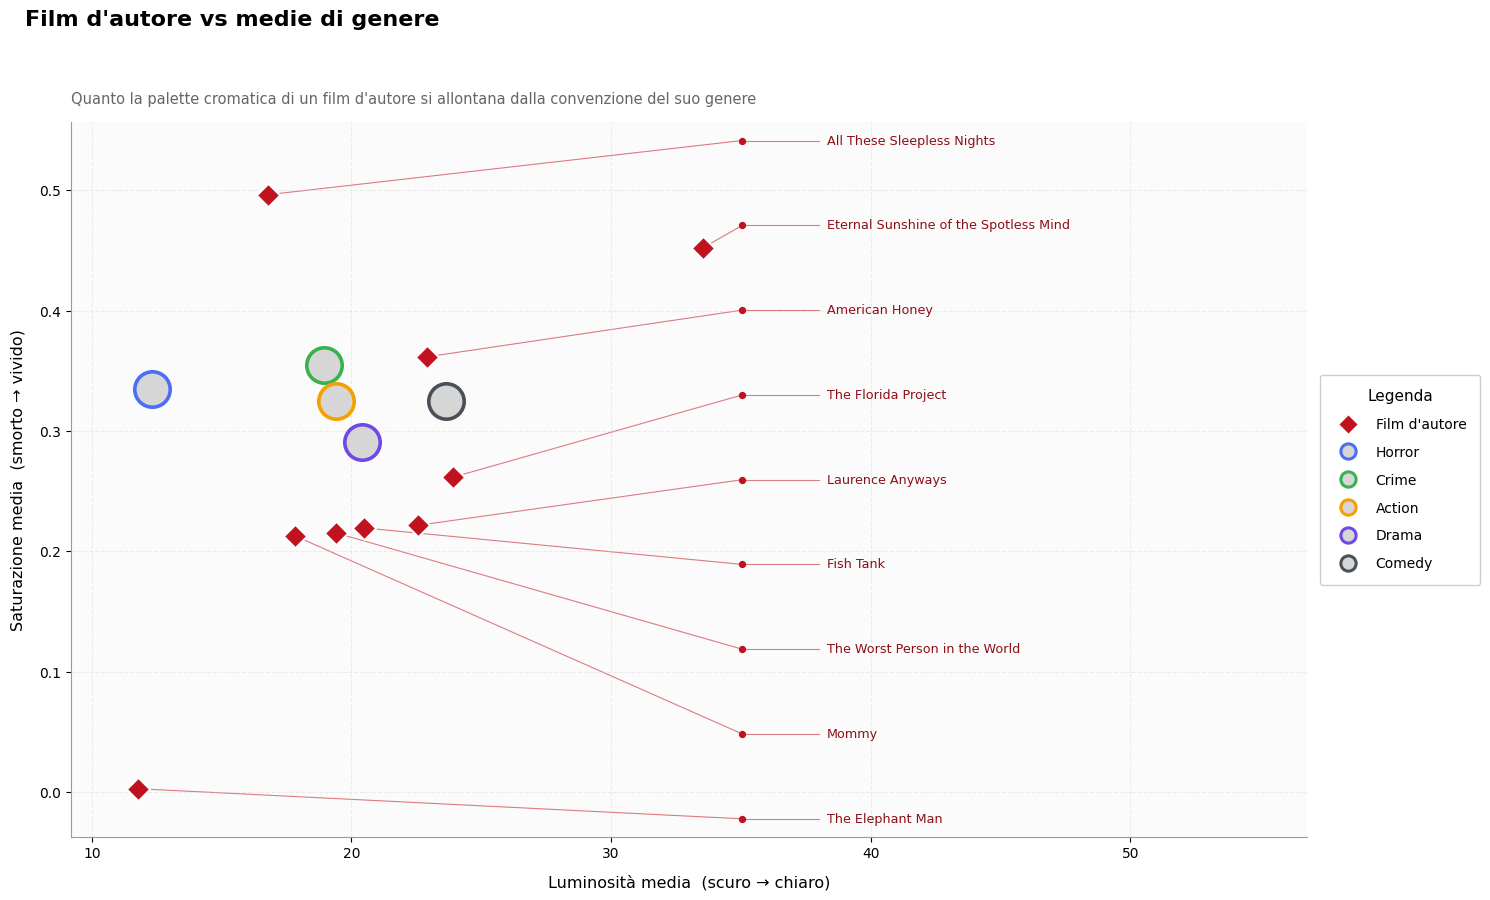

Come interpretare questo grafico:

- I cerchi (bordo colorato per genere, riquadro in alto collega
  ogni nome al proprio cerchio) sono le medie dei generi commerciali:
  notare quanto sono VICINI tra loro nello spazio luminosita'/
  saturazione (tranne Horror) - occupano una zona ristretta.

- I rombi rossi (con il nome collegato da una linea) sono i film
  d'autore. Piu' un punto e' LONTANO dal gruppo dei generi, piu' quel
  film rompe le convenzioni cromatiche.

- Il messaggio del grafico: la posizione in questo spazio non dice
  'che genere e'' un film, ma quanto un film si allontana dalla
  convenzione del suo genere - la cifra di uno sguardo autoriale forte.


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
from src.data_access import load_warehouse

# ============================================================
# DATI
# ============================================================
warehouse = load_warehouse()
warehouse_generi = warehouse[warehouse["genere_principale"] != "Auteur"]
generi_media = warehouse_generi.groupby("genere_principale")[["brightness_media", "saturation_media"]].mean()

auteur = pd.DataFrame(auteur_data)[["titolo", "anno", "brightness_media", "saturation_media", "temperature_media"]]
auteur = auteur.sort_values("saturation_media", ascending=False).reset_index(drop=True)

# ============================================================
# STILE
# ============================================================
plt.rcParams["font.family"] = "DejaVu Sans"
GRIGIO_GENERE = "#D6D6D6"
ROSSO = "#C1121F"
ROSSO_TESTO = "#8C0F16"

# Palette dedicata: un colore per genere, usato per bordo del cerchio +
# etichetta + connettore. Serve a rendere INEQUIVOCABILE quale etichetta
# appartiene a quale cerchio anche quando due generi hanno luminosita'
# quasi identica (es. Crime/Action) e le linee finiscono per incrociarsi:
# in quel caso seguire il colore risolve l'ambiguita' che una linea grigia
# uguale per tutti non risolverebbe. Se hai piu' o meno di 5 generi,
# aggiungi/rimuovi colori qui.
PALETTE_GENERI = ["#4C6EF5", "#37B24D", "#F59F00", "#7048E8", "#495057", "#E64980", "#0CA678"]

fig, ax = plt.subplots(figsize=(15, 9))
fig.patch.set_facecolor("white")
ax.set_facecolor("#FBFBFB")
ax.grid(True, linestyle="--", alpha=0.35, zorder=0, color="#CFCFCF")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#999999")

# ============================================================
# CERCHI DEI GENERI (bordo colorato, un colore per genere)
# ============================================================
x_max = max(generi_media["brightness_media"].max(), auteur["brightness_media"].max())
x_min_pts = min(generi_media["brightness_media"].min(), auteur["brightness_media"].min())
x_label = x_max + (x_max - x_min_pts) * 0.22
x_elbow = x_max + (x_max - x_min_pts) * 0.07
y_top = auteur["saturation_media"].max() + 0.06
y_bottom = min(auteur["saturation_media"].min(), generi_media["saturation_media"].min()) - 0.04

ax.set_xlim(x_min_pts - (x_max - x_min_pts) * 0.12, x_label + (x_max - x_min_pts) * 0.85)
ax.set_ylim(y_bottom, y_top)

generi_sorted = generi_media.sort_values("brightness_media")
colori_genere = dict(zip(generi_sorted.index, PALETTE_GENERI))

for genere, riga in generi_sorted.iterrows():
    colore = colori_genere[genere]
    x_c, y_c = riga["brightness_media"], riga["saturation_media"]
    ax.scatter([x_c], [y_c], s=650, c=GRIGIO_GENERE, edgecolors=colore,
               linewidth=2.6, zorder=2)

# ============================================================
# FILM D'AUTORE (rombi rossi)
# ============================================================
ax.scatter(auteur["brightness_media"], auteur["saturation_media"],
           s=140, c=ROSSO, edgecolors="white", linewidth=1.4,
           marker="D", zorder=5, label="Film d'autore")

# ============================================================
# ETICHETTE CON CONNETTORI "A GOMITO"
# (invece di una diagonale diretta punto -> testo, spezziamo la linea in
# due segmenti: un tratto obliquo breve fino a una colonna verticale
# comune, poi un tratto orizzontale fino al testo. Riduce moltissimo le
# linee che si incrociano rispetto a diagonali dirette su tutta la larghezza)
# ============================================================
n = len(auteur)
y_top_lab = auteur["saturation_media"].max() + 0.045
y_bottom_lab = auteur["saturation_media"].min() - 0.025
y_labels = np.linspace(y_top_lab, y_bottom_lab, n) if n > 1 else [auteur["saturation_media"].iloc[0]]

for i, riga in auteur.iterrows():
    y_lab = y_labels[i]
    x0, y0 = riga["brightness_media"], riga["saturation_media"]
    ax.plot([x0, x_elbow], [y0, y_lab], color=ROSSO, linewidth=0.8, alpha=0.55, zorder=1)
    ax.plot([x_elbow, x_label - 0.3], [y_lab, y_lab], color=ROSSO, linewidth=0.8, alpha=0.55, zorder=1)
    ax.scatter([x_elbow], [y_lab], s=18, c=ROSSO, zorder=6)
    ax.text(x_label, y_lab, riga["titolo"], fontsize=9.2, ha="left", va="center",
            color=ROSSO_TESTO, zorder=6)

ax.set_xlabel("Luminosità media  (scuro → chiaro)", fontsize=11.5, labelpad=10)
ax.set_ylabel("Saturazione media  (smorto → vivido)", fontsize=11.5, labelpad=10)

fig.suptitle("Film d'autore vs medie di genere", fontsize=16, fontweight="bold", x=0.02, ha="left", y=0.995)
ax.set_title("Quanto la palette cromatica di un film d'autore si allontana dalla convenzione del suo genere",
              fontsize=10.5, color="#666666", loc="left", pad=14)

legend_handles = [
    plt.Line2D([0], [0], marker="D", color="none", markerfacecolor=ROSSO,
               markeredgecolor="white", markeredgewidth=1.0, markersize=10,
               label="Film d'autore"),
]
for genere in generi_sorted.index:
    legend_handles.append(
        plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=GRIGIO_GENERE,
                   markeredgecolor=colori_genere[genere], markeredgewidth=2.2,
                   markersize=11, label=genere)
    )

legend = ax.legend(handles=legend_handles, loc="center left", fontsize=10,
                    framealpha=0.95, bbox_to_anchor=(1.005, 0.5), handletextpad=1.0,
                    borderpad=1.0, labelspacing=1.0, title="Legenda", title_fontsize=11,
                    frameon=True)
legend.get_frame().set_edgecolor("#CCCCCC")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../outputs/auteur_vs_genres.png", dpi=140, bbox_inches="tight")
plt.show()

print("Come interpretare questo grafico:")
print()
print("- I cerchi (bordo colorato per genere, riquadro in alto collega")
print("  ogni nome al proprio cerchio) sono le medie dei generi commerciali:")
print("  notare quanto sono VICINI tra loro nello spazio luminosita'/")
print("  saturazione (tranne Horror) - occupano una zona ristretta.")
print()
print("- I rombi rossi (con il nome collegato da una linea) sono i film")
print("  d'autore. Piu' un punto e' LONTANO dal gruppo dei generi, piu' quel")
print("  film rompe le convenzioni cromatiche.")
print()
print("- Il messaggio del grafico: la posizione in questo spazio non dice")
print("  'che genere e'' un film, ma quanto un film si allontana dalla")
print("  convenzione del suo genere - la cifra di uno sguardo autoriale forte.")